# 📊 Exam Score Prediction — Kaggle Playground Series S6E1
### Pipeline
1. Setup & Data Loading
2. Exploratory Data Analysis (EDA)
3. Encoding (ordinal maps fitted to actual data labels)
4. Feature Engineering
5. Prepare Pipeline
6. Model Definitions — Ridge | Random Forest | XGBoost | LightGBM | CatBoost
7. Feature Importance (diagnostic)
8. 10-Fold OOF Cross-Validation
9. Model Comparison Plots
10. Optuna Weighted Ensemble
11. Submission

## 1. Setup & Imports

In [ ]:
# %pip install lightgbm xgboost catboost optuna scikit-learn pandas numpy matplotlib seaborn -q

Note: you may need to restart the kernel to use updated packages.


In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Global config ──────────────────────────────────────────────────────────────
RANDOM_STATE = 42
N_FOLDS      = 10
SCORE_RANGE  = (0, 100)   # clip predictions to valid score range
COLORS       = ["#3498db", "#2ecc71", "#e74c3c", "#9b59b6", "#f39c12"]

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("Set2")

## 2. Data Loading

In [4]:
train = pd.read_csv("train.csv")
test  = pd.read_csv("test.csv")

print(f"Train : {train.shape}    Test : {test.shape}")
print(f"\nTarget — exam_score")
print(train["exam_score"].describe().round(3).to_string())
print(f"\nSkewness : {train['exam_score'].skew():.4f}  (near-zero → no log-transform needed)")
print(f"\nMissing values:\n{train.isnull().sum().to_string()}")
train.head()

Train : (630000, 13)    Test : (270000, 12)

Target — exam_score
count    630000.000
mean         62.507
std          18.917
min          19.599
25%          48.800
50%          62.600
75%          76.300
max         100.000

Skewness : -0.0483  (near-zero → no log-transform needed)

Missing values:
id                  0
age                 0
gender              0
course              0
study_hours         0
class_attendance    0
internet_access     0
sleep_hours         0
sleep_quality       0
study_method        0
facility_rating     0
exam_difficulty     0
exam_score          0


,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


## 3. Exploratory Data Analysis

Three panels:
- **(a)** Target distribution + numeric correlation heatmap
- **(b)** Boxplots of `exam_score` by every categorical feature
- **(c)** Scatter plots of numeric features vs target with trend lines

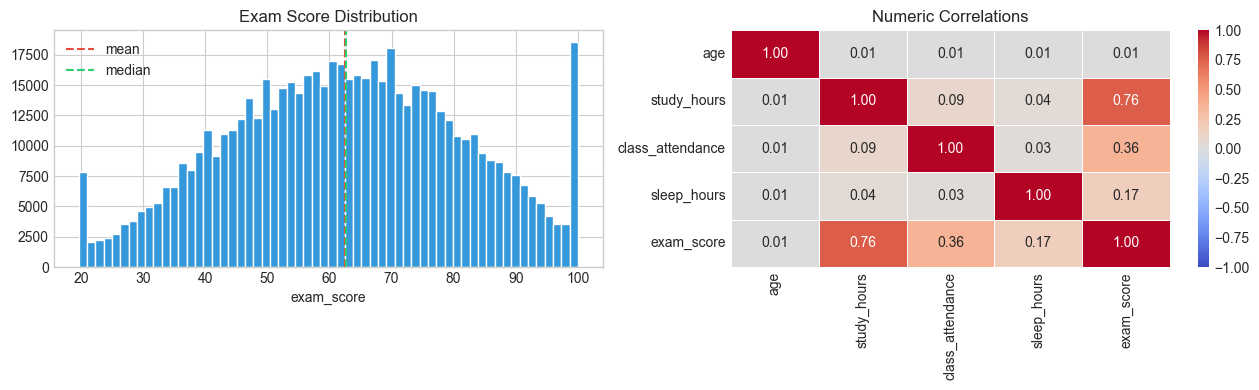

In [5]:
# ── (a) Target distribution & numeric correlations ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(train["exam_score"], bins=60, color="#3498db", edgecolor="white")
axes[0].axvline(train["exam_score"].mean(),   color="#e74c3c", ls="--", label="mean")
axes[0].axvline(train["exam_score"].median(), color="#2ecc71", ls="--", label="median")
axes[0].set_title("Exam Score Distribution")
axes[0].set_xlabel("exam_score")
axes[0].legend()

num_cols = ["age", "study_hours", "class_attendance", "sleep_hours", "exam_score"]
corr = train[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            ax=axes[1], linewidths=0.4, vmin=-1, vmax=1)
axes[1].set_title("Numeric Correlations")
plt.tight_layout()
plt.show()

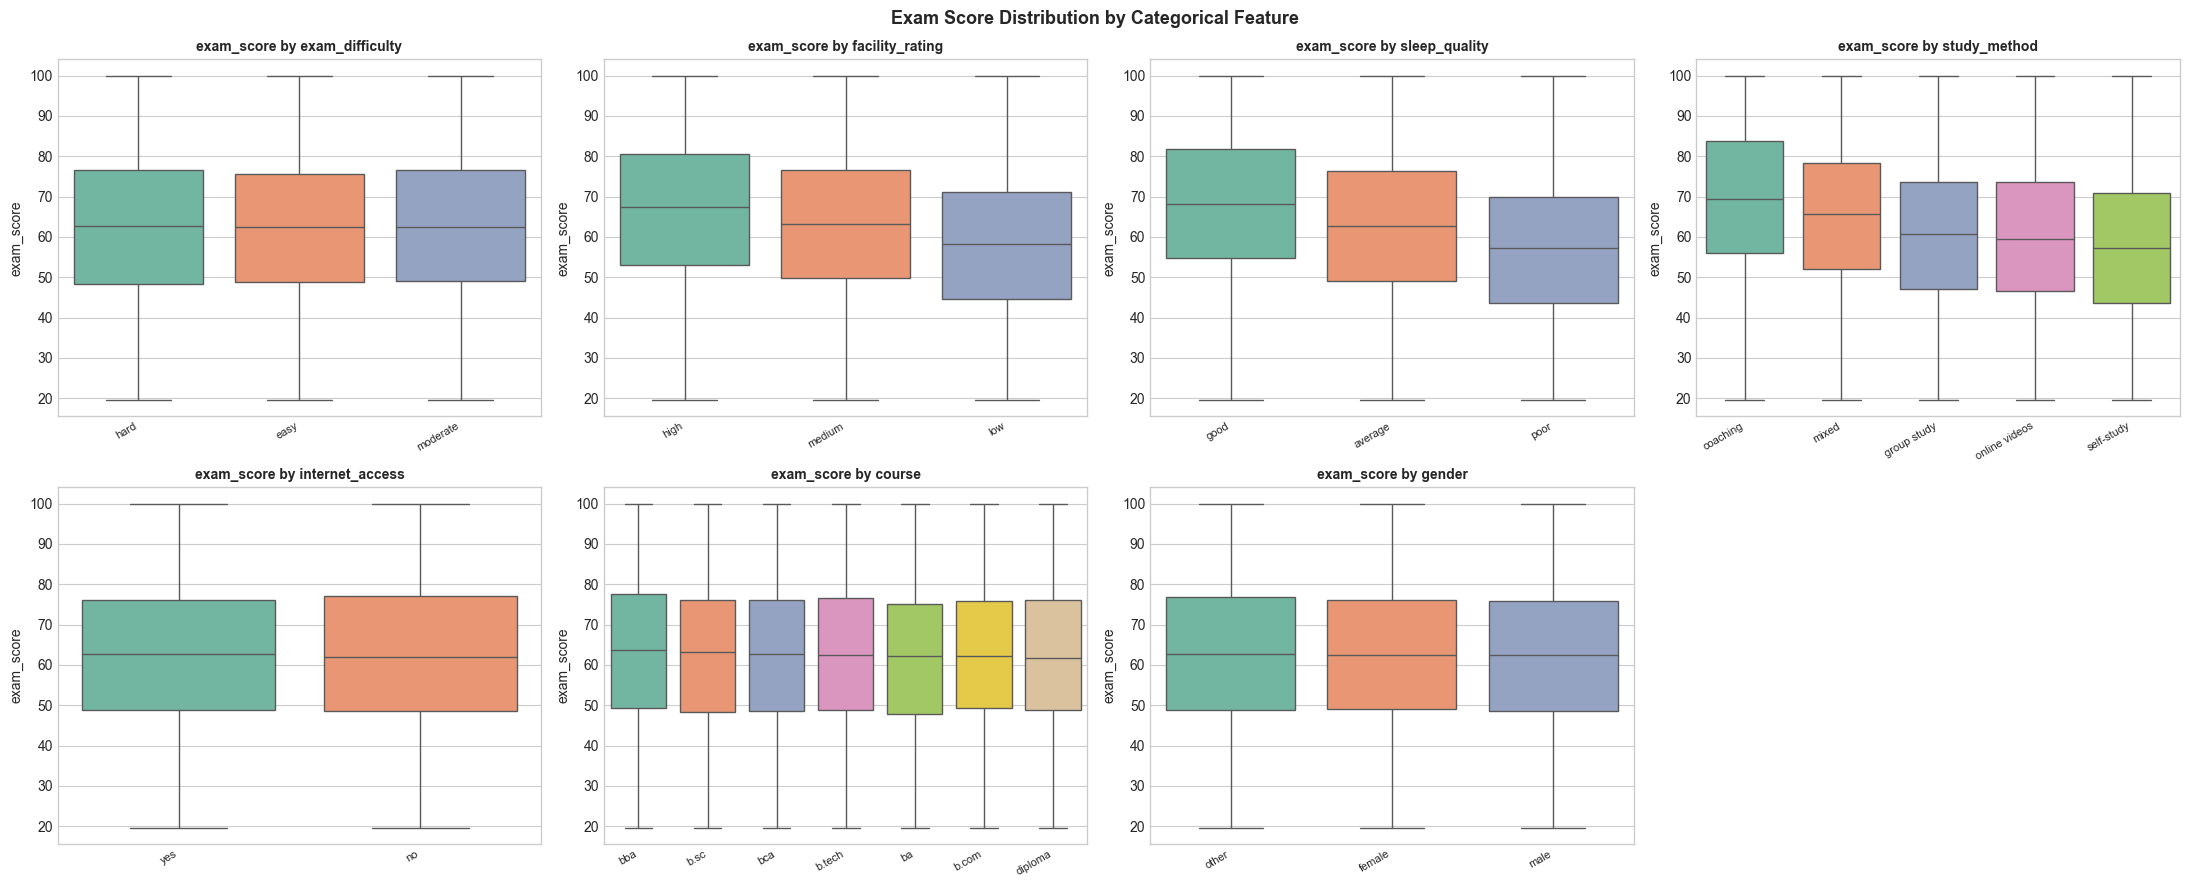

In [6]:
# ── (b) Categorical features vs exam_score ────────────────────────────────────
cat_cols = ["exam_difficulty", "facility_rating", "sleep_quality",
            "study_method", "internet_access", "course", "gender"]

fig, axes = plt.subplots(2, 4, figsize=(22, 9))
axes = axes.flatten()
for ax, col in zip(axes, cat_cols):
    order = (train.groupby(col)["exam_score"]
             .median().sort_values(ascending=False).index)
    sns.boxplot(data=train, x=col, y="exam_score", order=order,
                ax=ax, palette="Set2")
    ax.set_title(f"exam_score by {col}", fontsize=10, fontweight="bold")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha="right", fontsize=8)
    ax.set_xlabel("")
axes[-1].set_visible(False)
plt.suptitle("Exam Score Distribution by Categorical Feature",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

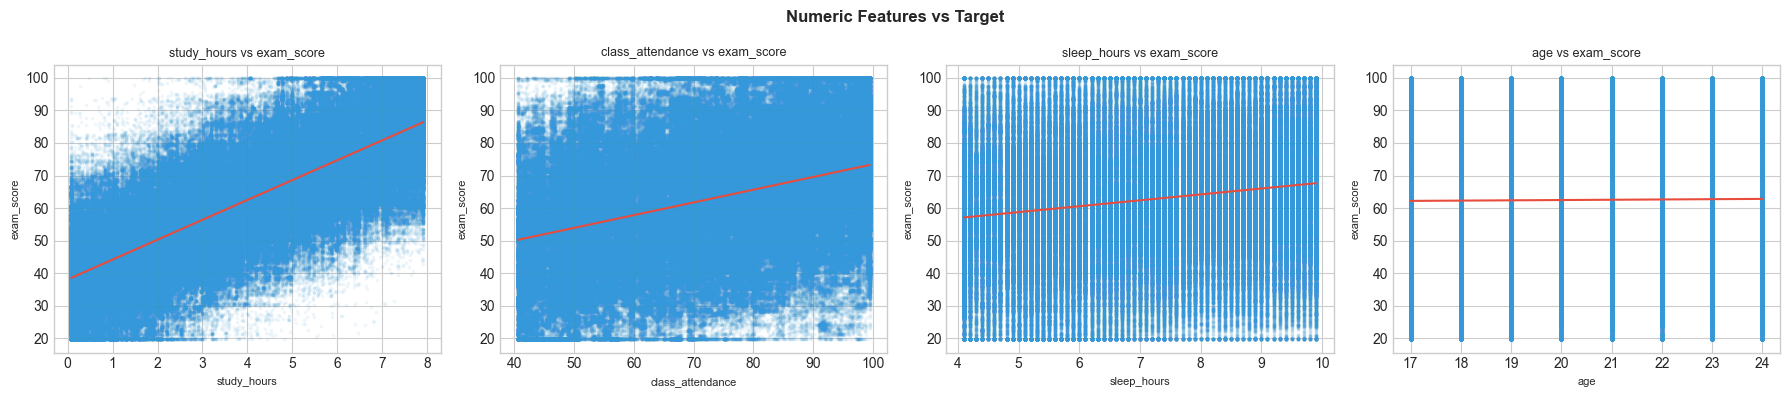

In [7]:
# ── (c) Numeric features vs target (scatter + trend line) ────────────────────
num_features = ["study_hours", "class_attendance", "sleep_hours", "age"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col in zip(axes, num_features):
    ax.scatter(train[col], train["exam_score"], alpha=0.05, s=3, color="#3498db")
    m, b = np.polyfit(train[col], train["exam_score"], 1)
    xs = np.linspace(train[col].min(), train[col].max(), 100)
    ax.plot(xs, m * xs + b, color="#e74c3c", lw=1.5)
    ax.set_title(f"{col} vs exam_score", fontsize=9)
    ax.set_xlabel(col, fontsize=8)
    ax.set_ylabel("exam_score", fontsize=8)
plt.suptitle("Numeric Features vs Target", fontweight="bold")
plt.tight_layout()
plt.show()

## 4. Encoding

All maps are fitted to the **actual unique values** found in the dataset — no guessing.

| Column | Type | Mapping |
|---|---|---|
| `sleep_quality` | Ordinal | poor→1, average→2, good→3 |
| `facility_rating` | Ordinal | low→1, medium→2, high→3 |
| `exam_difficulty` | Ordinal | easy→1, moderate→2, hard→3 |
| `study_method` | Ordinal (by empirical score rank) | self-study→1 … coaching→5 |
| `gender` | Label | female→0, other→1, male→2 |
| `course` | Label | diploma→0 … b.tech→6 |
| `internet_access` | Binary | no→0, yes→1 |

In [8]:
ORDINAL_MAPS = {
    "sleep_quality"  : {"poor": 1, "average": 2, "good": 3},
    "facility_rating": {"low": 1, "medium": 2, "high": 3},
    "exam_difficulty": {"easy": 1, "moderate": 2, "hard": 3},
}

STUDY_METHOD_MAP = {
    "self-study"   : 1,
    "online videos": 2,
    "group study"  : 3,
    "mixed"        : 4,
    "coaching"     : 5,
}

GENDER_MAP = {"female": 0, "other": 1, "male": 2}
COURSE_MAP = {c: i for i, c in enumerate(
                  ["diploma", "ba", "b.com", "bba", "bca", "b.sc", "b.tech"])}

def encode(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for col, mapping in ORDINAL_MAPS.items():
        df[col] = df[col].map(mapping)
    df["study_method"]    = df["study_method"].map(STUDY_METHOD_MAP)
    df["gender"]          = df["gender"].map(GENDER_MAP)
    df["course"]          = df["course"].map(COURSE_MAP)
    df["internet_access"] = (df["internet_access"] == "yes").astype(int)
    return df

## 5. Feature Engineering

| Feature | Rationale |
|---|---|
| `effort_score` | Weighted combo of study hours, attendance, study method |
| `sleep_efficiency` | Sleep quality ÷ sleep hours — quality matters more than quantity |
| `adj_effort` | Study hours ÷ exam difficulty — hard exams demand more prep |
| `resource_index` | Internet access + facility rating averaged |
| `study_x_attendance` | Compounding diligence interaction |
| `difficulty_x_resource` | Hard exam + poor resources = amplified struggle |
| `study_x_sleep`, `effort_x_sleep` | Sleep moderates study effectiveness |
| `at_risk` | Low effort + hard exam flag |
| `high_profile` | High effort + decent sleep flag |
| Polynomial terms | Captures diminishing returns in study hours, attendance, etc. |
| Ratio features | Study per sleep hour, attendance per difficulty unit |

In [9]:
def engineer(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # ── Composite effort ──────────────────────────────────────────────────────
    df["effort_score"] = (
        df["study_hours"]      * 0.40 +
        df["class_attendance"] * 0.40 +
        df["study_method"]     * 0.20
    )

    # ── Sleep efficiency ──────────────────────────────────────────────────────
    df["sleep_efficiency"] = df["sleep_quality"] / (df["sleep_hours"] + 1e-6)

    # ── Difficulty-adjusted effort ────────────────────────────────────────────
    df["adj_effort"] = df["study_hours"] / (df["exam_difficulty"] + 1e-6)

    # ── Resource index ────────────────────────────────────────────────────────
    df["resource_index"] = (df["internet_access"] + df["facility_rating"]) / 2

    # ── Interaction terms ─────────────────────────────────────────────────────
    df["study_x_attendance"]    = df["study_hours"]     * df["class_attendance"]
    df["difficulty_x_resource"] = df["exam_difficulty"] * df["resource_index"]
    df["study_x_sleep"]         = df["study_hours"]     * df["sleep_quality"]
    df["effort_x_sleep"]        = df["effort_score"]    * df["sleep_efficiency"]
    df["age_x_sleep"]           = df["age"]             * df["sleep_hours"]

    # ── Risk & performance flags ──────────────────────────────────────────────
    effort_q25     = df["effort_score"].quantile(0.25)
    effort_q75     = df["effort_score"].quantile(0.75)
    difficulty_q75 = df["exam_difficulty"].quantile(0.75)

    df["at_risk"]      = ((df["effort_score"]    < effort_q25) &
                          (df["exam_difficulty"] > difficulty_q75)).astype(int)
    df["high_profile"] = ((df["effort_score"] > effort_q75) &
                          (df["sleep_quality"] >= 2)).astype(int)

    # ── Polynomial terms ──────────────────────────────────────────────────────
    df["study_hours_sq"]     = df["study_hours"]      ** 2
    df["class_attend_sq"]    = df["class_attendance"] ** 2
    df["exam_difficulty_sq"] = df["exam_difficulty"]  ** 2
    df["effort_sq"]          = df["effort_score"]     ** 2

    # ── Ratio features ────────────────────────────────────────────────────────
    df["study_per_sleep"]       = df["study_hours"]       / (df["sleep_hours"]     + 1e-6)
    df["attend_per_difficulty"] = df["class_attendance"]  / (df["exam_difficulty"] + 1e-6)

    return df

## 6. Prepare Pipeline

Encode and engineer on the **combined** train+test frame to ensure consistent label encoding, then split back.

In [10]:
y   = train["exam_score"].copy()
ids = test["id"].copy()

train_proc = train.drop(columns=["exam_score", "id"])
test_proc  = test.drop(columns=["id"])

combined = pd.concat([train_proc, test_proc], axis=0, ignore_index=True)
combined = encode(combined)
combined = engineer(combined)

n_tr   = len(train_proc)
X      = combined.iloc[:n_tr].reset_index(drop=True)
X_test = combined.iloc[n_tr:].reset_index(drop=True)

print(f"Total features after engineering : {X.shape[1]}")
print(f"Feature list : {list(X.columns)}")
X.head()

Total features after engineering : 28
Feature list : ['age', 'gender', 'course', 'study_hours', 'class_attendance', 'internet_access', 'sleep_hours', 'sleep_quality', 'study_method', 'facility_rating', 'exam_difficulty', 'effort_score', 'sleep_efficiency', 'adj_effort', 'resource_index', 'study_x_attendance', 'difficulty_x_resource', 'study_x_sleep', 'effort_x_sleep', 'age_x_sleep', 'at_risk', 'high_profile', 'study_hours_sq', 'class_attend_sq', 'exam_difficulty_sq', 'effort_sq', 'study_per_sleep', 'attend_per_difficulty']


,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,...,effort_x_sleep,age_x_sleep,at_risk,high_profile,study_hours_sq,class_attend_sq,exam_difficulty_sq,effort_sq,study_per_sleep,attend_per_difficulty
0,21,0,5,7.91,98.8,0,4.9,2,2,1,...,17.585303,102.9,0,1,62.5681,9761.44,1,1856.231056,1.614285,98.799901
1,18,1,0,4.95,94.8,1,4.7,1,1,2,...,8.531913,84.6,0,0,24.5025,8987.04,4,1608.010000,1.053191,47.399976
2,20,0,5,4.68,92.6,1,5.8,1,5,3,...,6.881378,116.0,0,0,21.9024,8574.76,4,1592.967744,0.806896,46.299977
3,19,2,5,2.00,49.5,1,8.3,2,3,3,...,5.108433,157.7,0,0,4.0000,2450.25,4,449.440000,0.240964,24.749988
4,23,2,4,7.65,86.9,1,9.6,3,1,3,...,11.881249,220.8,0,1,58.5225,7551.61,1,1445.520400,0.796875,86.899913


## 7. Feature Importance (Quick LightGBM Diagnostic)

Run a single LightGBM on the full training set before CV to see which features matter most.
🔴 Red bars = engineered features &nbsp;&nbsp; 🔵 Blue bars = original features

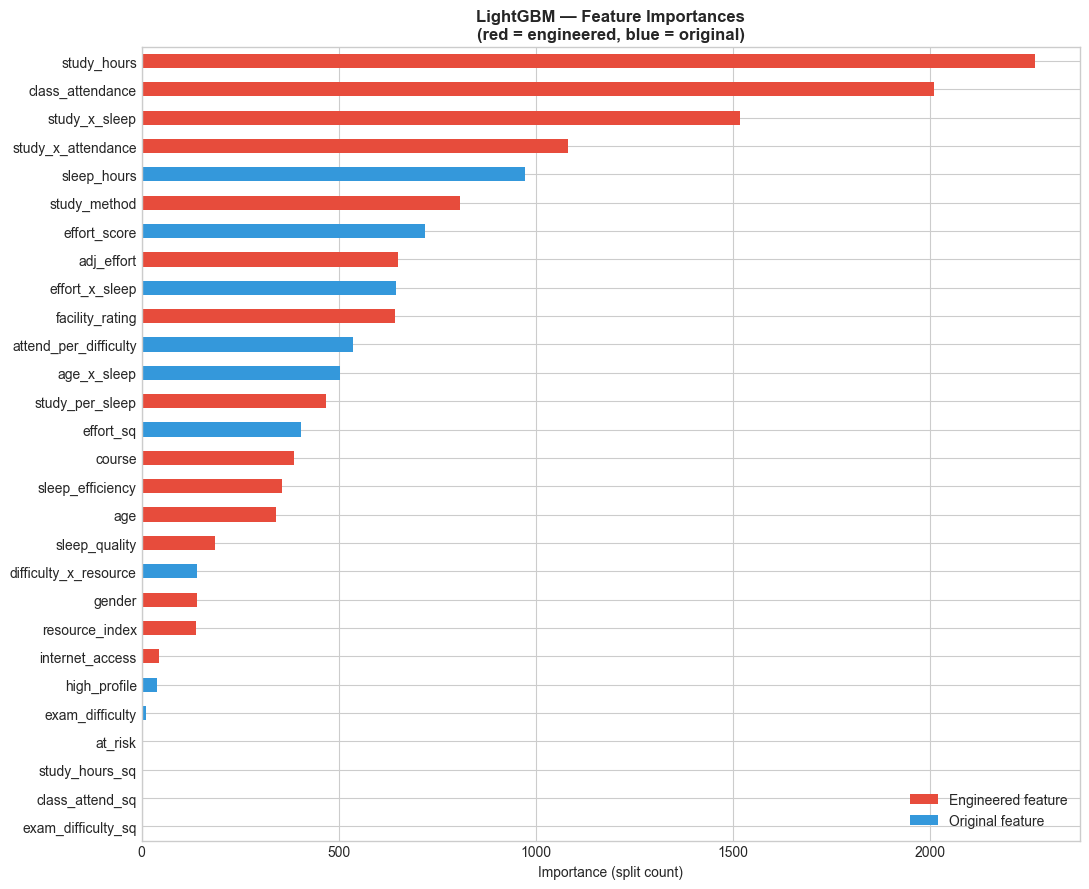

In [11]:
ENGINEERED = {
    "effort_score", "sleep_efficiency", "adj_effort", "resource_index",
    "study_x_attendance", "difficulty_x_resource", "study_x_sleep",
    "effort_x_sleep", "age_x_sleep", "at_risk", "high_profile",
    "study_hours_sq", "class_attend_sq", "exam_difficulty_sq",
    "effort_sq", "study_per_sleep", "attend_per_difficulty"
}

_imp_model = LGBMRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=7,
    random_state=RANDOM_STATE, verbose=-1, n_jobs=-1
)
_imp_model.fit(X, y)
imp = (pd.Series(_imp_model.feature_importances_, index=X.columns)
         .sort_values(ascending=False))

bar_colors = ["#e74c3c" if f in ENGINEERED else "#3498db" for f in imp.index]

fig, ax = plt.subplots(figsize=(11, 9))
imp.plot(kind="barh", ax=ax, color=bar_colors[::-1])
ax.invert_yaxis()
ax.set_title("LightGBM — Feature Importances\n(red = engineered, blue = original)",
             fontweight="bold")
ax.set_xlabel("Importance (split count)")

from matplotlib.patches import Patch
ax.legend(handles=[Patch(facecolor="#e74c3c", label="Engineered feature"),
                   Patch(facecolor="#3498db", label="Original feature")],
          loc="lower right")
plt.tight_layout()
plt.show()

## 8. Model Definitions

| Model | Role |
|---|---|
| **Ridge** | Linear baseline — shows how much non-linearity actually matters |
| **Random Forest** | Bagging ensemble, diversity contributor |
| **XGBoost** | Boosted trees, strong individual performer |
| **LightGBM** | Fast boosted trees, usually the top scorer |
| **CatBoost** | Gradient boosting with ordered boosting, handles encodings robustly |

In [12]:
def get_models() -> dict:
    return {
        "Ridge": Ridge(alpha=10.0),

        "RandomForest": RandomForestRegressor(
            n_estimators=400, max_depth=14, min_samples_leaf=5,
            max_features=0.6, random_state=RANDOM_STATE, n_jobs=-1
        ),

        "XGBoost": XGBRegressor(
            n_estimators=1500, learning_rate=0.02, max_depth=7,
            subsample=0.8, colsample_bytree=0.75,
            reg_alpha=0.1, reg_lambda=1.5,
            random_state=RANDOM_STATE, verbosity=0,
            n_jobs=-1, tree_method="hist"
        ),

        "LightGBM": LGBMRegressor(
            n_estimators=1500, learning_rate=0.02, max_depth=7,
            num_leaves=80, subsample=0.8, colsample_bytree=0.75,
            reg_alpha=0.1, reg_lambda=1.5,
            random_state=RANDOM_STATE, verbose=-1, n_jobs=-1
        ),

        "CatBoost": CatBoostRegressor(
            iterations=1500, learning_rate=0.02, depth=7,
            l2_leaf_reg=3.0, subsample=0.8,
            random_seed=RANDOM_STATE, verbose=0
        ),
    }

## 9. 10-Fold OOF Cross-Validation

- **KFold** (not stratified — regression task)
- Ridge uses **StandardScaler**; tree models use raw features
- OOF predictions are accumulated for ensemble optimisation
- Test predictions are **averaged across all 10 folds**

In [13]:
models     = get_models()
scaler     = StandardScaler()
kf         = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)

oof_preds  = {n: np.zeros(len(X))      for n in models}
test_preds = {n: np.zeros(len(X_test)) for n in models}
cv_scores  = {n: []                    for n in models}

X_scaled      = pd.DataFrame(scaler.fit_transform(X),      columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test),     columns=X.columns)

for fold, (tr_idx, val_idx) in enumerate(kf.split(X), 1):
    print(f"\n── Fold {fold}/{N_FOLDS} ──────────────────────────────────")

    X_tr,    X_val    = X.iloc[tr_idx],        X.iloc[val_idx]
    X_tr_sc, X_val_sc = X_scaled.iloc[tr_idx], X_scaled.iloc[val_idx]
    y_tr,    y_val    = y.iloc[tr_idx],         y.iloc[val_idx]

    for name, model in models.items():
        if name == "Ridge":
            model.fit(X_tr_sc, y_tr)
            val_pred  = model.predict(X_val_sc)
            test_pred = model.predict(X_test_scaled)
        else:
            model.fit(X_tr, y_tr)
            val_pred  = model.predict(X_val)
            test_pred = model.predict(X_test)

        oof_preds[name][val_idx]  = val_pred
        test_preds[name]         += test_pred / N_FOLDS

        rmse = root_mean_squared_error(y_val, val_pred)
        cv_scores[name].append(rmse)
        print(f"  {name:<14}  RMSE = {rmse:.4f}")

oof_df  = pd.DataFrame(oof_preds)
test_df = pd.DataFrame(test_preds)

print("\n══════  CV Summary  ══════════════════════════════════════")
for name, scores in cv_scores.items():
    print(f"  {name:<14}  {np.mean(scores):.4f} ± {np.std(scores):.4f}")


── Fold 1/10 ──────────────────────────────────
  Ridge           RMSE = 8.9293
  RandomForest    RMSE = 8.8396
  XGBoost         RMSE = 8.7140
  LightGBM        RMSE = 8.7177
  CatBoost        RMSE = 8.7551

── Fold 2/10 ──────────────────────────────────
  Ridge           RMSE = 8.9777
  RandomForest    RMSE = 8.8958
  XGBoost         RMSE = 8.7723
  LightGBM        RMSE = 8.7739
  CatBoost        RMSE = 8.8073

── Fold 3/10 ──────────────────────────────────
  Ridge           RMSE = 8.9257
  RandomForest    RMSE = 8.8407
  XGBoost         RMSE = 8.7183
  LightGBM        RMSE = 8.7264
  CatBoost        RMSE = 8.7626

── Fold 4/10 ──────────────────────────────────
  Ridge           RMSE = 8.9906
  RandomForest    RMSE = 8.8970
  XGBoost         RMSE = 8.7772
  LightGBM        RMSE = 8.7827
  CatBoost        RMSE = 8.8220

── Fold 5/10 ──────────────────────────────────
  Ridge           RMSE = 8.9461
  RandomForest    RMSE = 8.8447
  XGBoost         RMSE = 8.7298
  LightGBM        R

## 10. Model Comparison Plots

Four views:
- **Bar chart** — mean RMSE ± std across folds
- **Box plot** — fold-level RMSE distribution
- **Rank heatmap** — which model wins each fold (1 = best)
- **Residual scatter** — predicted vs residual per model (first 3 shown)

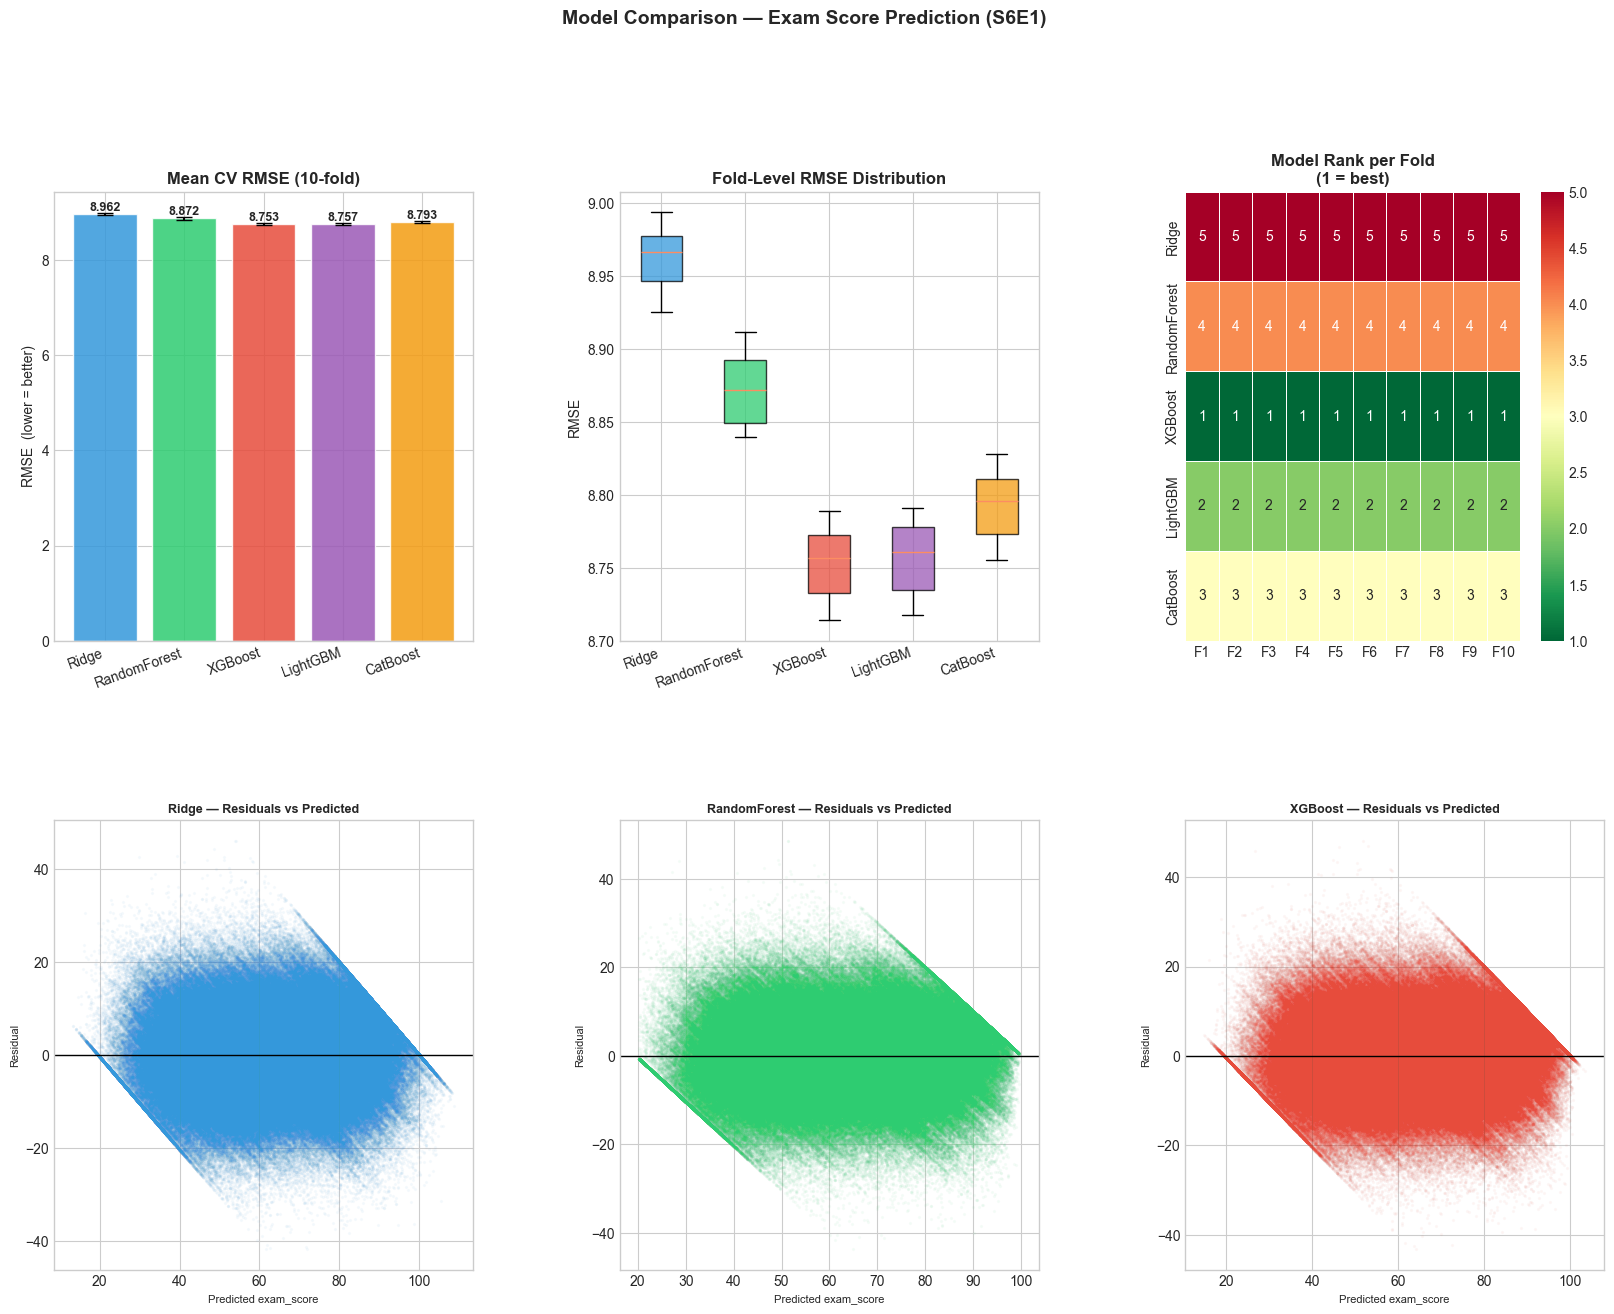

In [ ]:
names = list(cv_scores.keys())
means = [np.mean(cv_scores[n]) for n in names]
stds  = [np.std(cv_scores[n])  for n in names]

fig = plt.figure(figsize=(20, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.40, wspace=0.35)

# Bar chart
ax0  = fig.add_subplot(gs[0, 0])
bars = ax0.bar(names, means, yerr=stds, capsize=6,
               color=COLORS, edgecolor="white", alpha=0.85)
ax0.set_title("Mean CV RMSE (10-fold)", fontweight="bold")
ax0.set_ylabel("RMSE  (lower = better)")
ax0.set_xticklabels(names, rotation=20, ha="right")
for bar, m, s in zip(bars, means, stds):
    ax0.text(bar.get_x() + bar.get_width() / 2, m + s + 0.05,
             f"{m:.3f}", ha="center", fontsize=9, fontweight="bold")

# Box plot
ax1 = fig.add_subplot(gs[0, 1])
bp  = ax1.boxplot([cv_scores[n] for n in names], labels=names,
                  patch_artist=True, notch=False)
for patch, color in zip(bp["boxes"], COLORS):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax1.set_title("Fold-Level RMSE Distribution", fontweight="bold")
ax1.set_ylabel("RMSE")
ax1.set_xticklabels(names, rotation=20, ha="right")

# Rank heatmap
ax2         = fig.add_subplot(gs[0, 2])
fold_matrix = np.array([cv_scores[n] for n in names])
rank_matrix = fold_matrix.argsort(axis=0).argsort(axis=0) + 1
sns.heatmap(rank_matrix,
            xticklabels=[f"F{i+1}" for i in range(N_FOLDS)],
            yticklabels=names,
            annot=True, fmt="d", cmap="RdYlGn_r",
            linewidths=0.4, ax=ax2, vmin=1, vmax=len(names))
ax2.set_title("Model Rank per Fold\n(1 = best)", fontweight="bold")

# Residual scatter (first 3 models)
for i, name in enumerate(names[:3]):
    ax = fig.add_subplot(gs[1, i])
    residuals = y.values - oof_df[name].values
    ax.scatter(oof_df[name].values, residuals, alpha=0.03, s=2, color=COLORS[i])
    ax.axhline(0, color="black", lw=1)
    ax.set_title(f"{name} — Residuals vs Predicted", fontsize=9, fontweight="bold")
    ax.set_xlabel("Predicted exam_score", fontsize=8)
    ax.set_ylabel("Residual", fontsize=8)

plt.suptitle("Model Comparison — Exam Score Prediction",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

**Top Row**
- Mean CV RMSE (left): Lower is better. XGBoost (8.753) and LightGBM (8.757) are best, then CatBoost, then RandomForest, and Ridge worst.
- Fold RMSE boxplots (middle): Shows variability across folds. XGBoost/LightGBM have both low center and tight spread → strong + stable.
- Rank heatmap (right): Rank 1 is best each fold. It shows XGBoost consistently rank 1, LightGBM rank 2, etc., meaning ordering is very stable across folds.

**Bottom Row (Residuals vs Predicted)**
- Residuals are mostly centered near 0 (good), with wider spread in some score regions (heteroscedasticity). The triangular shape is expected because scores are bounded near 0–100.

**Overall Takeaway**
- XGBoost is your strongest single model, LightGBM is extremely close, and both are reliable candidates for the weighted ensemble.

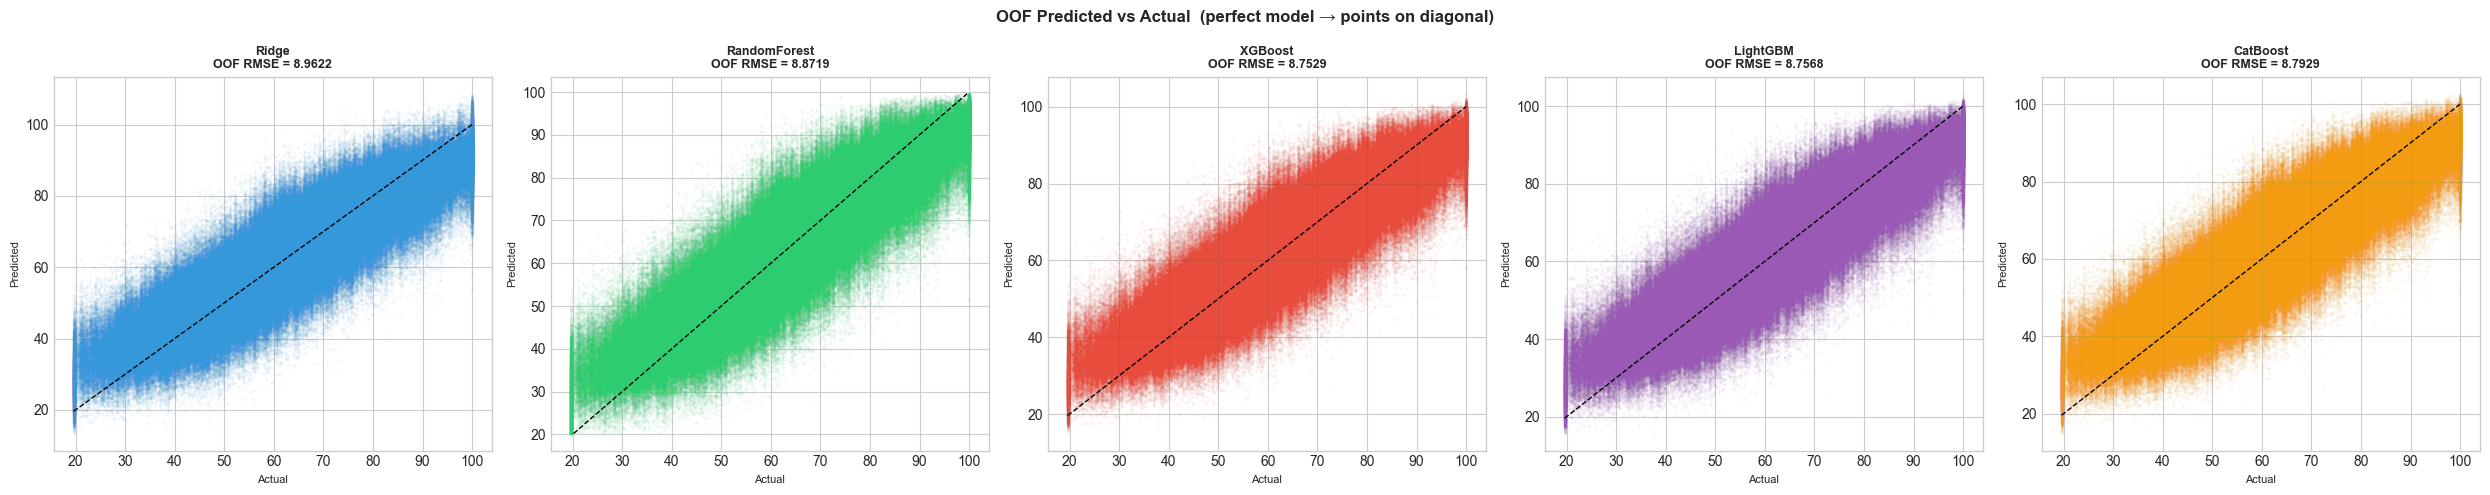

In [15]:
# ── OOF Predicted vs Actual ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(names), figsize=(5 * len(names), 5))
for ax, name, color in zip(axes, names, COLORS):
    ax.scatter(y, oof_df[name], alpha=0.03, s=2, color=color)
    lims = [max(y.min(), oof_df[name].min()), min(y.max(), oof_df[name].max())]
    ax.plot(lims, lims, "k--", lw=1)
    rmse = root_mean_squared_error(y, oof_df[name])
    ax.set_title(f"{name}\nOOF RMSE = {rmse:.4f}", fontsize=9, fontweight="bold")
    ax.set_xlabel("Actual", fontsize=8)
    ax.set_ylabel("Predicted", fontsize=8)
plt.suptitle("OOF Predicted vs Actual  (perfect model → points on diagonal)",
             fontweight="bold")
plt.tight_layout()
plt.show()

## 11. Optuna Weighted Ensemble

Searches for weights $w_i \geq 0$, $\sum w_i = 1$ that minimise the OOF RMSE of the blended prediction.
Uses **300 TPE trials** — takes ~30 seconds.

In [16]:
def find_best_weights(oof_df, y):
    names = oof_df.columns.tolist()

    def objective(trial):
        raw   = np.array([trial.suggest_float(f"w_{n}", 0.0, 1.0) for n in names])
        w     = raw / (raw.sum() + 1e-9)
        blend = (oof_df.values * w).sum(axis=1)
        return root_mean_squared_error(y, blend)

    study = optuna.create_study(
        direction="minimize",
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
    )
    study.optimize(objective, n_trials=300, show_progress_bar=False)

    best = study.best_params
    raw  = np.array([best[f"w_{n}"] for n in names])
    w    = raw / raw.sum()
    return dict(zip(names, w))

weights = find_best_weights(oof_df, y)

print("══════  Ensemble Weights  ════════════════════════════════")
for name, wt in weights.items():
    print(f"  {name:<14}  {wt:.4f}")

w_arr      = np.array([weights[n] for n in oof_df.columns])
blend_rmse = root_mean_squared_error(y, (oof_df.values * w_arr).sum(axis=1))
print(f"\n  Ensemble OOF RMSE : {blend_rmse:.4f}")

══════  Ensemble Weights  ════════════════════════════════
  Ridge           0.0007
  RandomForest    0.0006
  XGBoost         0.6161
  LightGBM        0.3825
  CatBoost        0.0001

  Ensemble OOF RMSE : 8.7493


## 12. Generate Submission

Blend test predictions using the optimised weights and clip to `[0, 100]`.

In [18]:
w     = np.array([weights[n] for n in test_df.columns])
preds = np.clip((test_df.values * w).sum(axis=1), *SCORE_RANGE)

submission = pd.DataFrame({"id": ids, "exam_score": np.round(preds, 1)})
submission.to_csv("submission.csv", index=False)

print(f"Submission saved → submission.csv  ({len(submission):,} rows)")
print(submission.head(10))
print(f"\nPrediction stats:")
print(submission["exam_score"].describe().round(3).to_string())

Submission saved → submission.csv  (270,000 rows)
       id  exam_score
0  630000        71.3
1  630001        70.8
2  630002        87.9
3  630003        55.6
4  630004        47.5
5  630005        71.6
6  630006        73.3
7  630007        58.3
8  630008        78.4
9  630009        91.0

Prediction stats:
count    270000.000
mean         62.519
std          16.741
min          15.400
25%          49.400
50%          63.000
75%          75.400
max         100.000
